## Workspace setup

In [ ]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [1]:
from datetime import datetime  
import uproot
from functools import partial
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

import importlib

# Notebooks run from VSCode use home directory as a base path
# while notebooks run from JupyterLab use the current directory as a base path
import sys, os

user = os.getenv("USER")
if user == None:
    sys.path.append("/home/jovyan/TPCReco/PythonAnalysis/python/")
    os.chdir("/home/jovyan/TPCReco/PythonAnalysis/")
else:
    sys.path.append("/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/")
    os.chdir('/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/ipynb/')

# os.makedirs("fig_png", exist_ok=True)

2026-05-17 15:37:23.423261: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-17 15:37:23.455161: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-17 15:37:24.392233: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Training dataset preparation

In [3]:
import io_functions as io
importlib.reload(io)

batchSize = 16
dataset = tf.data.Dataset.load('MergedEvent_Track3D_TwoProng_gun_MC_50k', compression="GZIP")
dataset = dataset.batch(batchSize, drop_remainder=True)
dataset = dataset.map(lambda x: x['sim'])
dataset = dataset.map(lambda x,y: (tf.reshape(x, (-1,)+io.projections.shape), tf.reshape(y, (-1,9))))
dataset = dataset.prefetch(tf.data.AUTOTUNE)

nBatches = tf.data.experimental.cardinality(dataset).numpy()
print('number of batches: ', nBatches)

dataset = dataset.take(nBatches).cache()
tfds.benchmark(dataset.take(nBatches), batch_size=batchSize)

number of batches:  2766

************ Summary ************



  0%|          | 0/2766 [00:00<?, ?it/s]

Examples/sec (First included) 265.29 ex/sec (total: 44272 ex, 166.88 sec)
Examples/sec (First only) 140.65 ex/sec (total: 16 ex, 0.11 sec)
Examples/sec (First excluded) 265.38 ex/sec (total: 44256 ex, 166.77 sec)


2026-05-17 15:41:24.870529: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,duration,num_examples,avg
first+lasts,166.881421,44272,265.290167
first,0.113755,16,140.653442
lasts,166.767666,44256,265.375184


In [4]:
x, y = next(iter(dataset.take(1)))

print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (16, 256, 512, 3)
y shape: (16, 9)


## Model definition

In [11]:
def getModel_xyz_old():

    model = tf.keras.Sequential([
      tf.keras.layers.Input(shape=(256,512,3), name="input_image", dtype=tf.float32),
      tf.keras.layers.Conv2D(filters = 16*3, kernel_size = (16,32), groups=3,
                             padding='same', activation='relu', 
                             data_format="channels_last"),
      tf.keras.layers.MaxPooling2D(pool_size=(16, 32)),
      tf.keras.layers.Conv2D(filters=16*3, kernel_size=(8,16), groups=3,
                              padding='same', activation='relu', 
                              data_format="channels_last"),
      tf.keras.layers.MaxPooling2D(),
      tf.keras.layers.Conv2D(filters=8*3, kernel_size=2, groups=3, 
                             padding='same', activation='relu', 
                              data_format="channels_last"),
      tf.keras.layers.Flatten(),
      tf.keras.layers.Dense(16, activation='relu',
                              kernel_initializer=tf.keras.initializers.HeNormal(),
                              bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
      tf.keras.layers.Dense(16, activation='relu',
                              kernel_initializer=tf.keras.initializers.HeNormal(),
                              bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
      tf.keras.layers.Dense(16, activation='relu',
                              kernel_initializer=tf.keras.initializers.HeNormal(),
                              bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
      tf.keras.layers.Dense(16, activation='relu',
                              kernel_initializer=tf.keras.initializers.HeNormal(),
                              bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
      tf.keras.layers.Dense(9, activation="linear")
      ])

    initial_learning_rate = 0.01
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate,
                      decay_steps=1990,
                      decay_rate=0.98,
                      staircase=False)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule) 
    model.compile(optimizer = optimizer, 
                    loss = 'mse', 
                    metrics=['mse', 'mape']) 
    
    model.summary()
    return model
##########################################################

## Model training

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 512, 48)   │        24,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 48)     │        98,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 24)       │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        24,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 9)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150,097 (586.32 KB)

 Trainable params: 150,097 (586.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


2026-04-28 12:10:44.752081: I external/local_xla/xla/service/service.cc:163] XLA service 0x717d440156e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-28 12:10:44.752106: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L40S, Compute Capability 8.9
2026-04-28 12:10:44.752108: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA L40S, Compute Capability 8.9
2026-04-28 12:10:44.774302: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-28 12:10:44.923434: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-04-28 12:10:46.879963: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng46{k2=1,k5=2,k14=5} for conv (f32[256,48,256,512]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,3,271,543]{3,2,1,0}, f

164/164 ━━━━━━━━━━━━━━━━━━━━ 177s 771ms/step - loss: 853.0843 - mse: 853.0843 - val_loss: 355.8442 - val_mse: 355.8442
Epoch 2/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - loss: 287.0841 - mse: 287.0841 - val_loss: 236.9067 - val_mse: 236.9067
Epoch 3/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - loss: 188.1027 - mse: 188.1027 - val_loss: 150.9851 - val_mse: 150.9851
Epoch 4/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - loss: 146.0295 - mse: 146.0295 - val_loss: 133.5143 - val_mse: 133.5143
Epoch 5/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - loss: 133.8635 - mse: 133.8635 - val_loss: 124.1464 - val_mse: 124.1464
Epoch 6/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - loss: 122.4749 - mse: 122.4749 - val_loss: 109.5226 - val_mse: 109.5226
Epoch 7/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 172s 1000ms/step - loss: 108.9335 - mse: 108.9335 - val_loss: 94.8540 - val_mse: 94.8540
Epoch 8/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - loss: 91.7945 - mse: 91.7945 - val_loss: 75.3238 - val_mse: 75

NameError: name 'epochs' is not defined

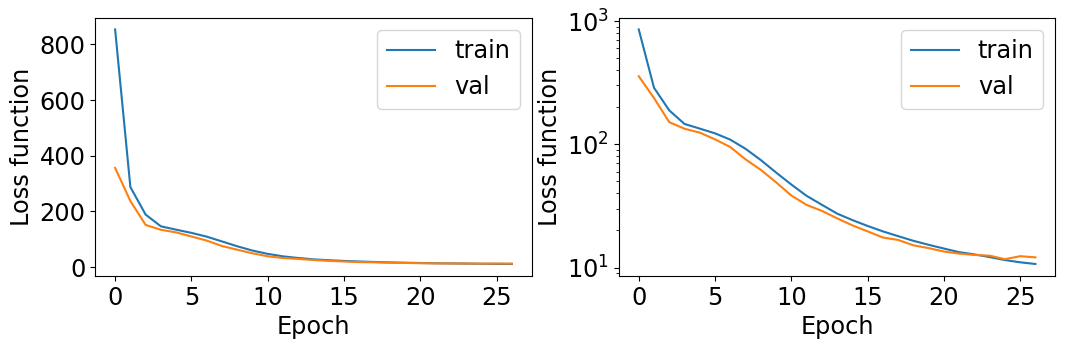

In [5]:
%%time
import plotting_functions as plf
importlib.reload(plf)

model = getModel_1()
# log_dir = "logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
early_stop_callback = tf.keras.callbacks.EarlyStopping(patience=2, verbose=1, restore_best_weights=True)
callbacks =  [early_stop_callback] 

Nepochs=50
model.trainable = True

initial_learning_rate = 1E-3
decay_steps = 5*nBatches
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate,
                  decay_steps=decay_steps,
                  decay_rate=0.98,
                  staircase=False)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule) 
model.compile(optimizer = optimizer, 
                loss = 'mse', 
                metrics=['mse']) 

history = model.fit(dataset.skip(nBatches//20), 
                        epochs=Nepochs,
                        verbose = 1,
                        validation_data = dataset.take(nBatches//20),
                        callbacks=callbacks
                        )
plf.plotTrainHistory(history)

# job_dir = f"training/{epochs:04d}_"+current_time+"/"
# model.export(job_dir)

In [6]:
# current_time = datetime.now().strftime("%Y_%b_%d_%H_%M_%S")
# print("Training start. Current Time =", current_time)

# job_dir = f"training/{Nepochs:04d}_"+current_time+".keras"
# model.save(job_dir)

Training start. Current Time = 2026_Apr_28_13_32_59


## Model performance on training data.

Fill Pandas DataFrame with true and response values.

In [14]:
%%time
import utility_functions as utils
importlib.reload(utils)
import pandas as pd
model_path = "./training/0050_2026_Apr_28_13_32_59.keras" # val_mse: 12.0836, 50k, early_stopping: 27

#model_path = "./training/0010_2026_Mar_27_15_08_49.keras" #  val_mse: 3.0631
#model_path = "./training/0100_2026_Mar_27_17_45_38.keras" #  val_mse: 1.5725
model = tf.keras.models.load_model(model_path)
data = np.zeros_like(utils.getSimRecoColumns(utils.columnsXYZ).reshape(1,-1), dtype=float) 

for aBatch in dataset.take(500):
    features = aBatch[0]
    labels = aBatch[1].numpy()
    modelAnswer = model(features).numpy()
    data = np.append(data, np.column_stack((labels,modelAnswer)), axis=0)

df_XYZ = pd.DataFrame(data=data[1:], columns = utils.getSimRecoColumns(utils.columnsXYZ))
df_XYZ.describe()  

CPU times: user 2min 30s, sys: 27.5 s, total: 2min 57s
Wall time: 1min 53s


,xVtx_sim,xAlpha_sim,xCarbon_sim,yVtx_sim,yAlpha_sim,yCarbon_sim,zVtx_sim,zAlpha_sim,zCarbon_sim,xVtx_reco,xAlpha_reco,xCarbon_reco,yVtx_reco,yAlpha_reco,yCarbon_reco,zVtx_reco,zAlpha_reco,zCarbon_reco
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,0.322112,-0.950784,-0.283886,-0.012455,-0.225565,0.019970,-35.691250,-36.313494,-35.611222,-0.744022,-0.665604,-1.770119,-0.031370,-1.439591,-0.074535,-34.872463,-36.317075,-34.734355
std,57.407473,64.648595,58.241073,0.993353,33.090762,5.647807,23.096982,28.435152,27.871203,57.857824,64.729857,58.636878,0.483106,33.028268,5.303528,23.270913,28.334161,28.104804
min,-99.989540,-139.864563,-114.022804,-3.799604,-89.919418,-14.738889,-52.945583,-66.150398,-52.946159,-107.343208,-150.764450,-119.728424,-4.335231,-102.034622,-17.480700,-56.209751,-65.337723,-65.843529
25%,-49.700338,-52.064154,-50.051031,-0.666929,-18.643254,-4.302907,-49.497767,-52.934366,-52.946159,-51.304585,-52.238653,-52.066170,-0.302784,-20.205409,-3.151229,-49.089580,-52.332331,-51.564440
50%,0.580938,-2.009143,0.025264,-0.019495,-0.426193,0.019949,-45.261631,-52.206566,-52.265232,-0.578069,-1.344466,-1.170656,-0.021356,-1.707152,-0.159146,-45.075851,-50.345903,-49.284819
75%,49.934445,49.821545,49.967244,0.659135,18.272003,4.346972,-33.143672,-29.780362,-28.466293,49.623928,51.173050,48.817904,0.271625,17.121641,2.886841,-31.628588,-30.275789,-28.222681
max,99.998215,139.840469,113.220901,4.076410,89.970024,14.271210,47.381966,66.130165,62.964664,109.997643,154.195496,116.122185,2.418103,101.922623,17.953407,54.678791,82.448639,70.163185


2026-05-12 14:21:39.125989: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


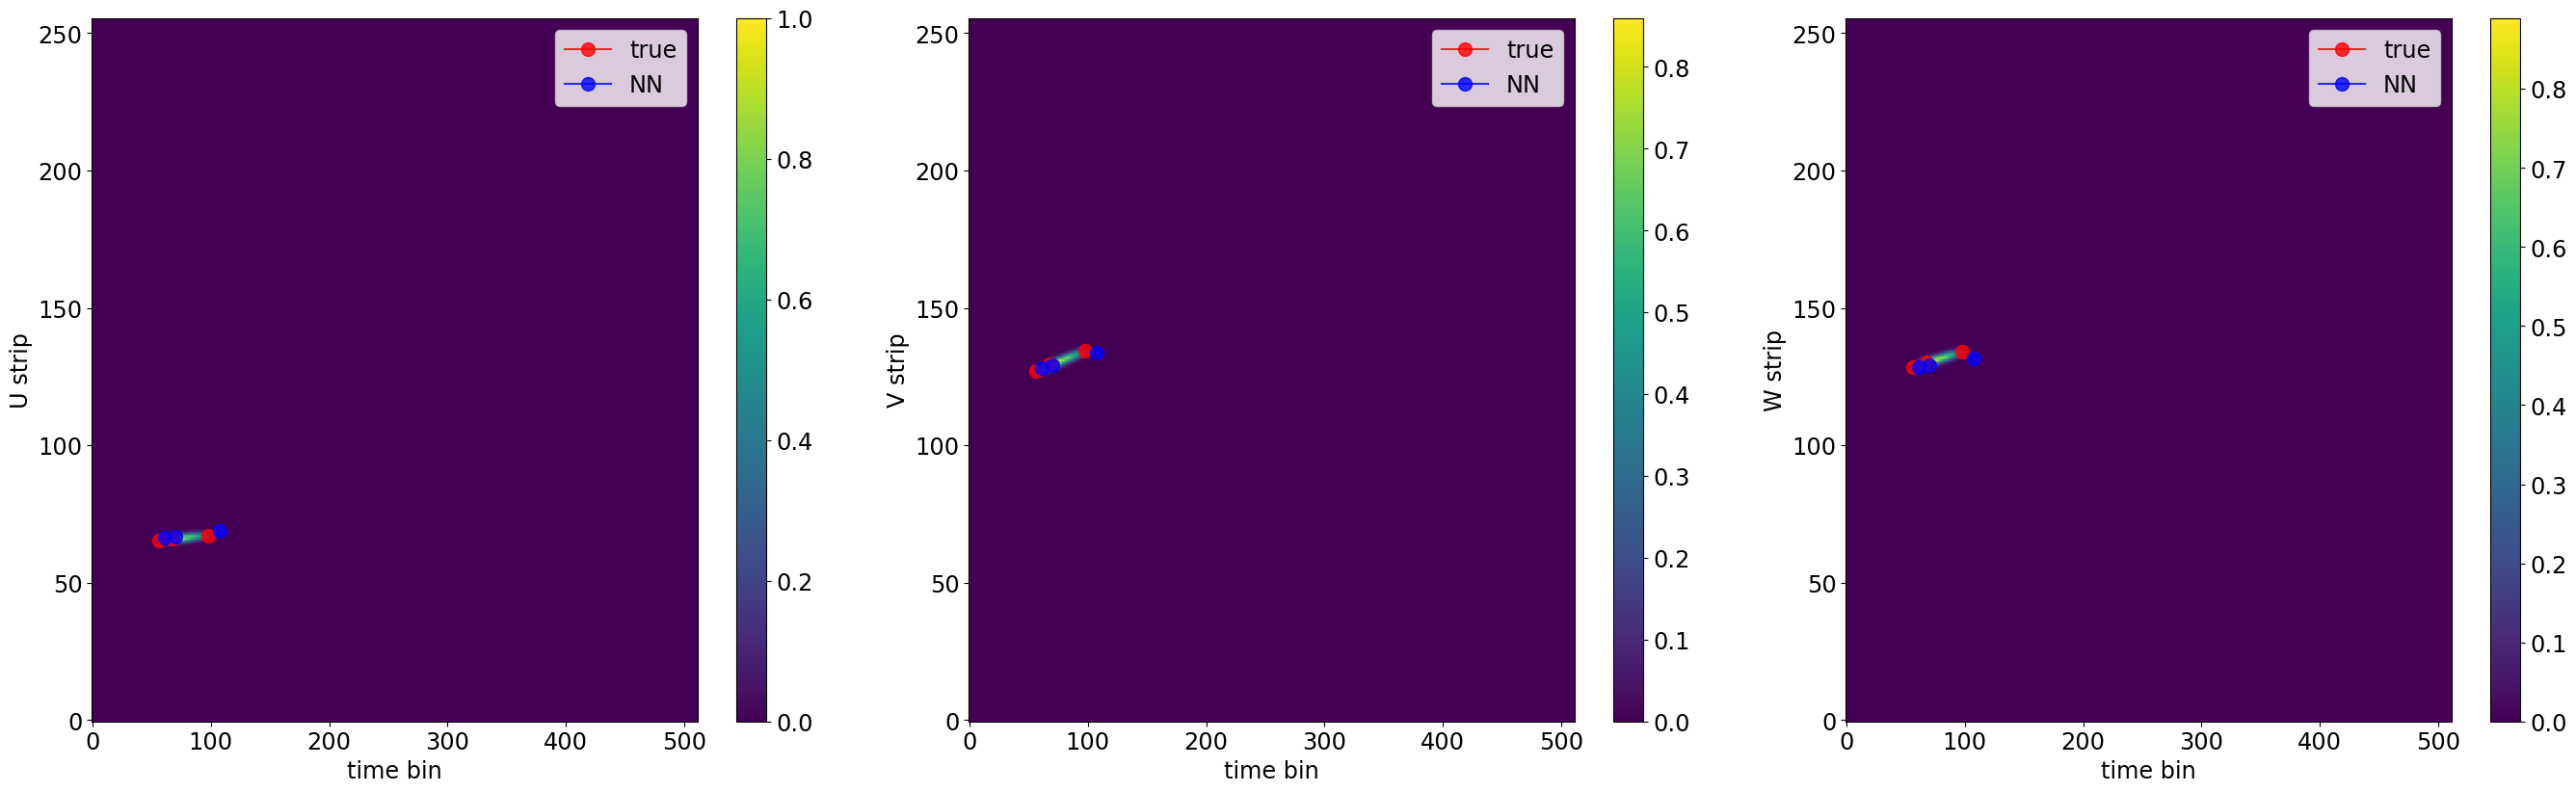

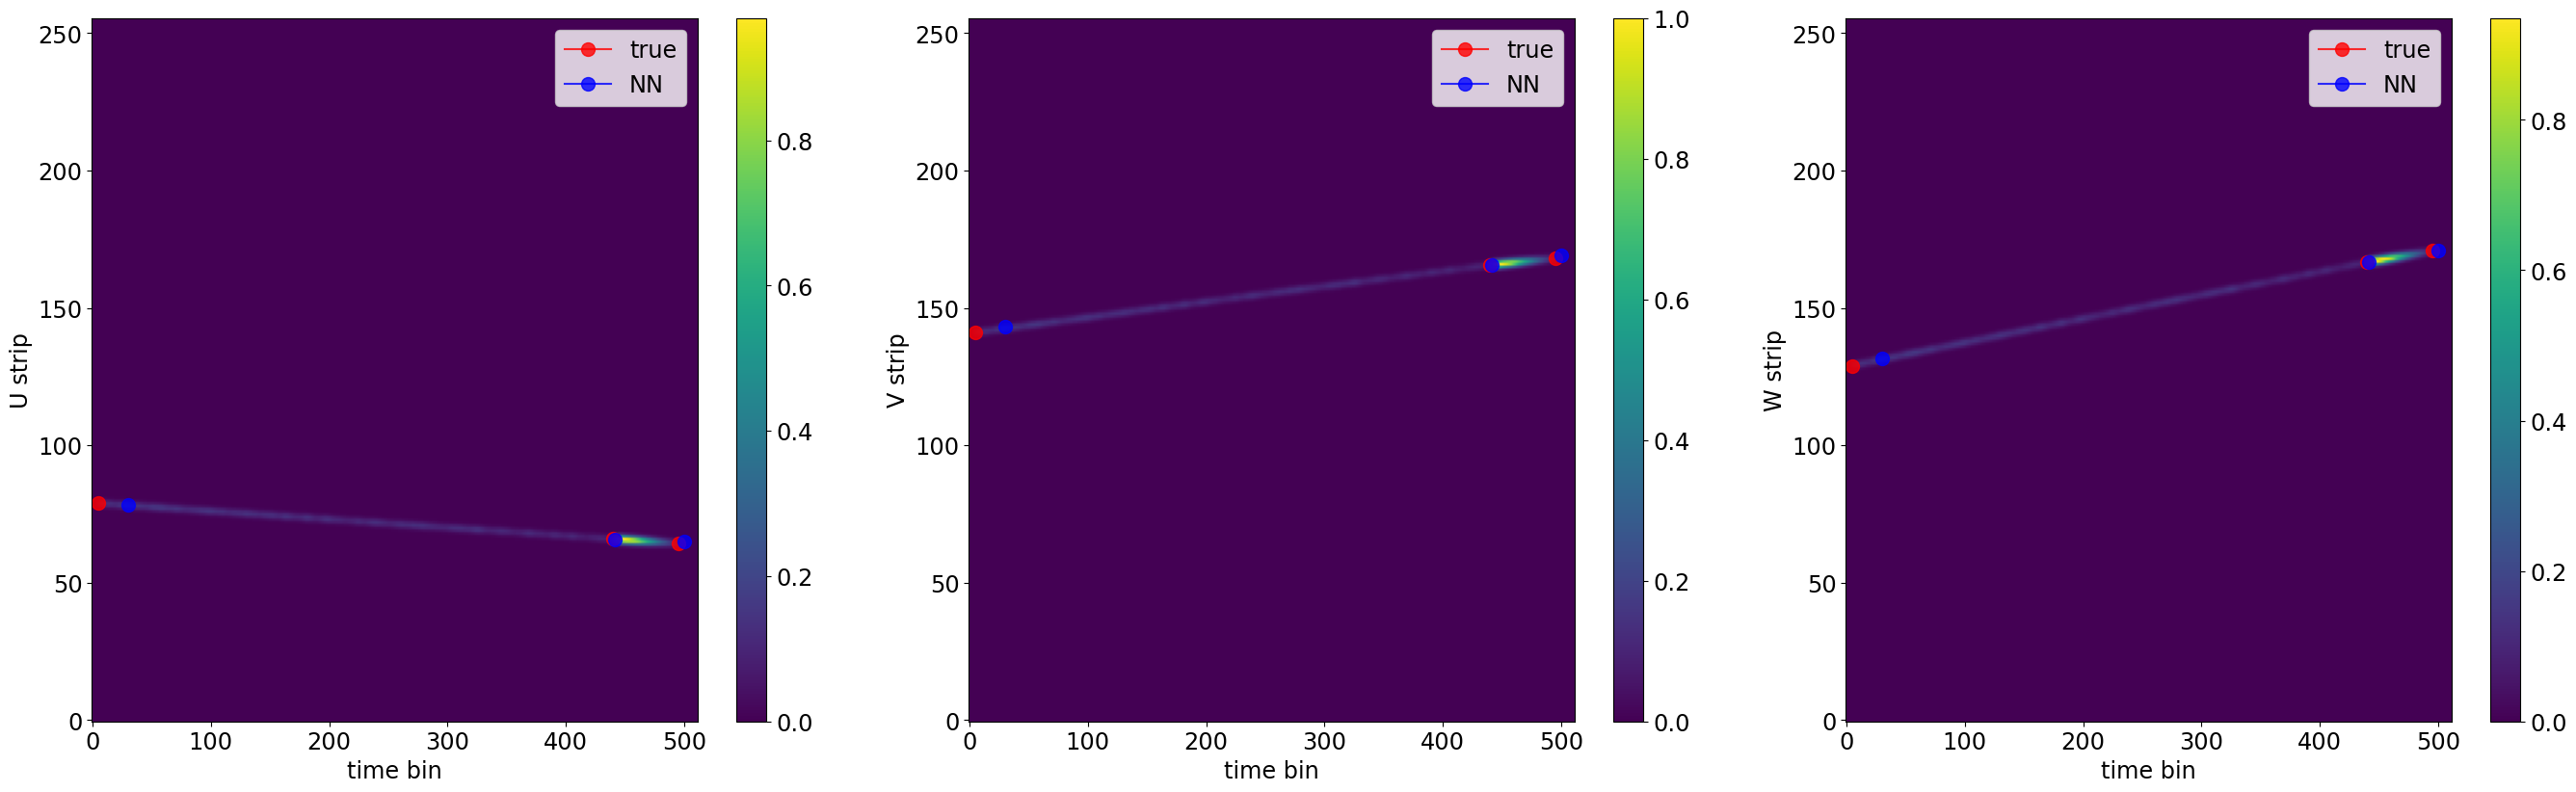

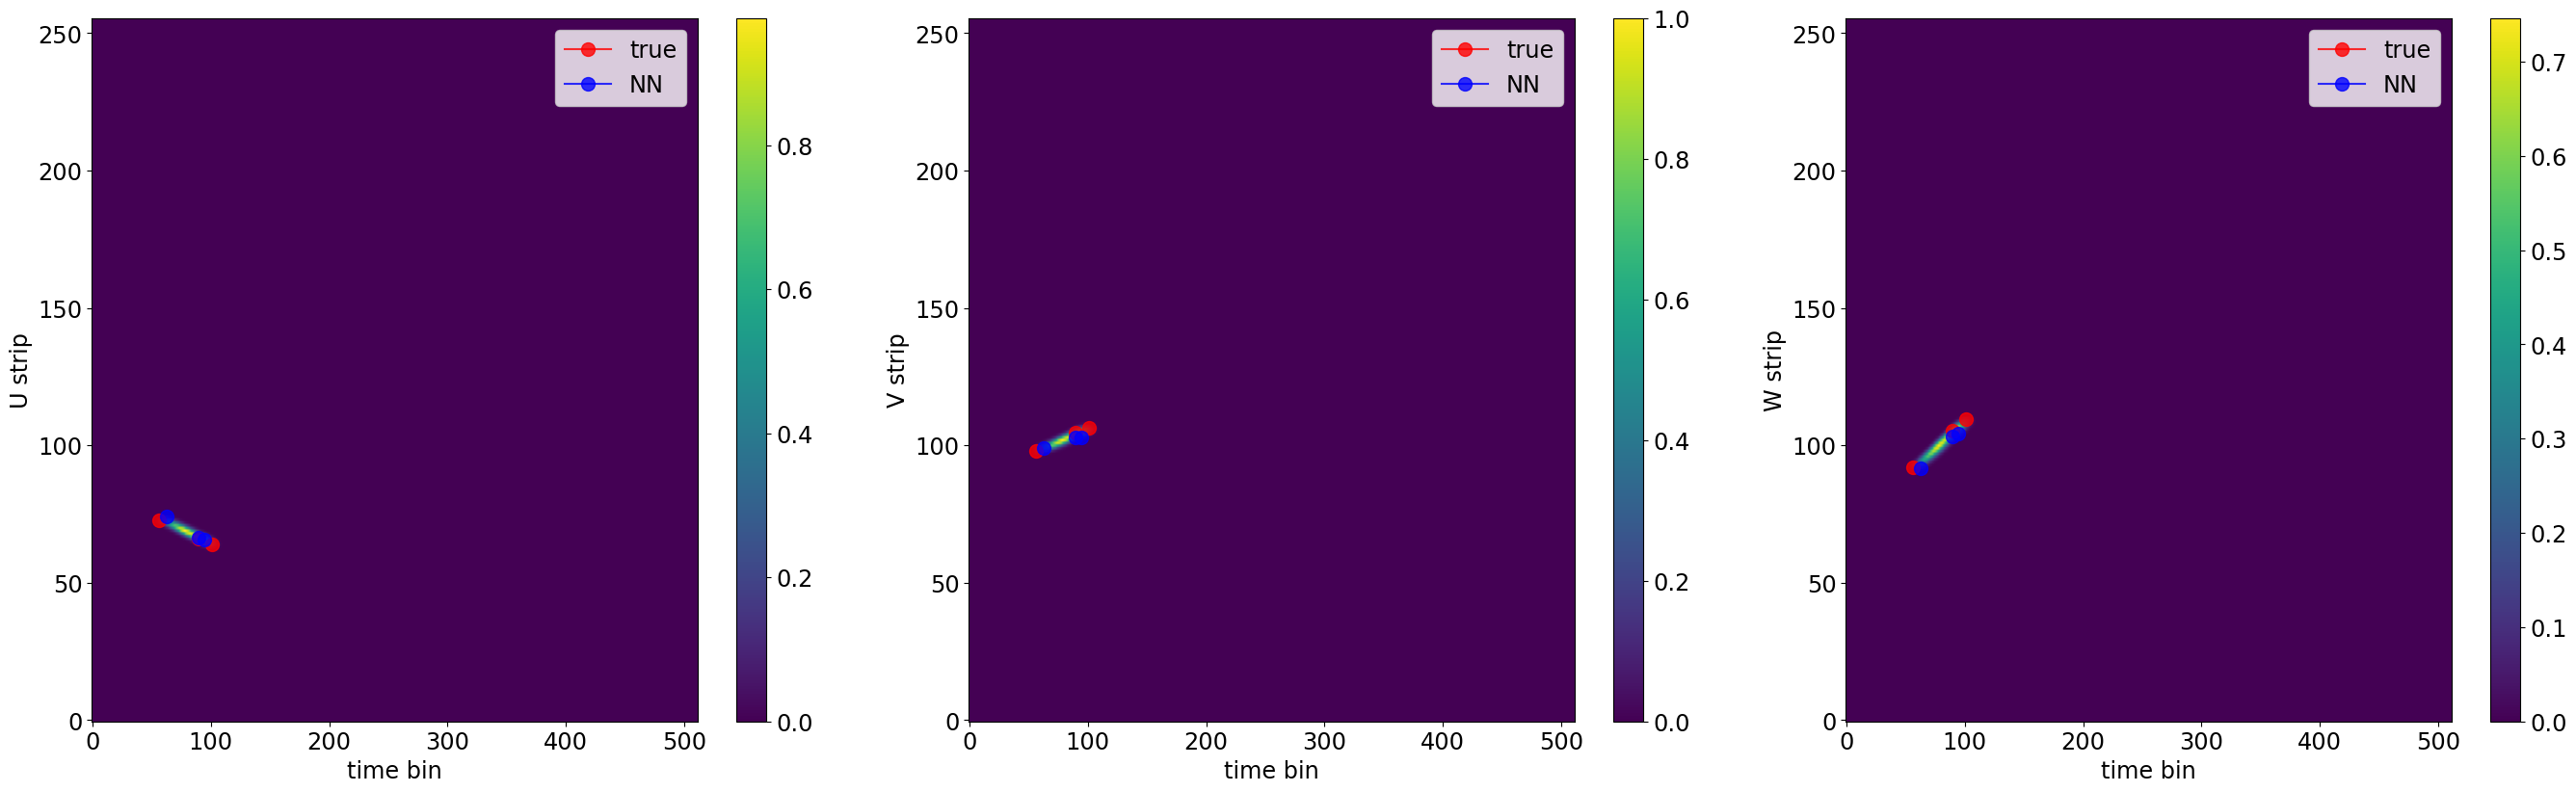

In [5]:
import plotting_functions as plf
importlib.reload(plf)

import utility_functions as utils
importlib.reload(utils)

for aBatch in dataset.skip(100).take(3):
    plf.plotEvent(aBatch, model=model)

### Resolution plots

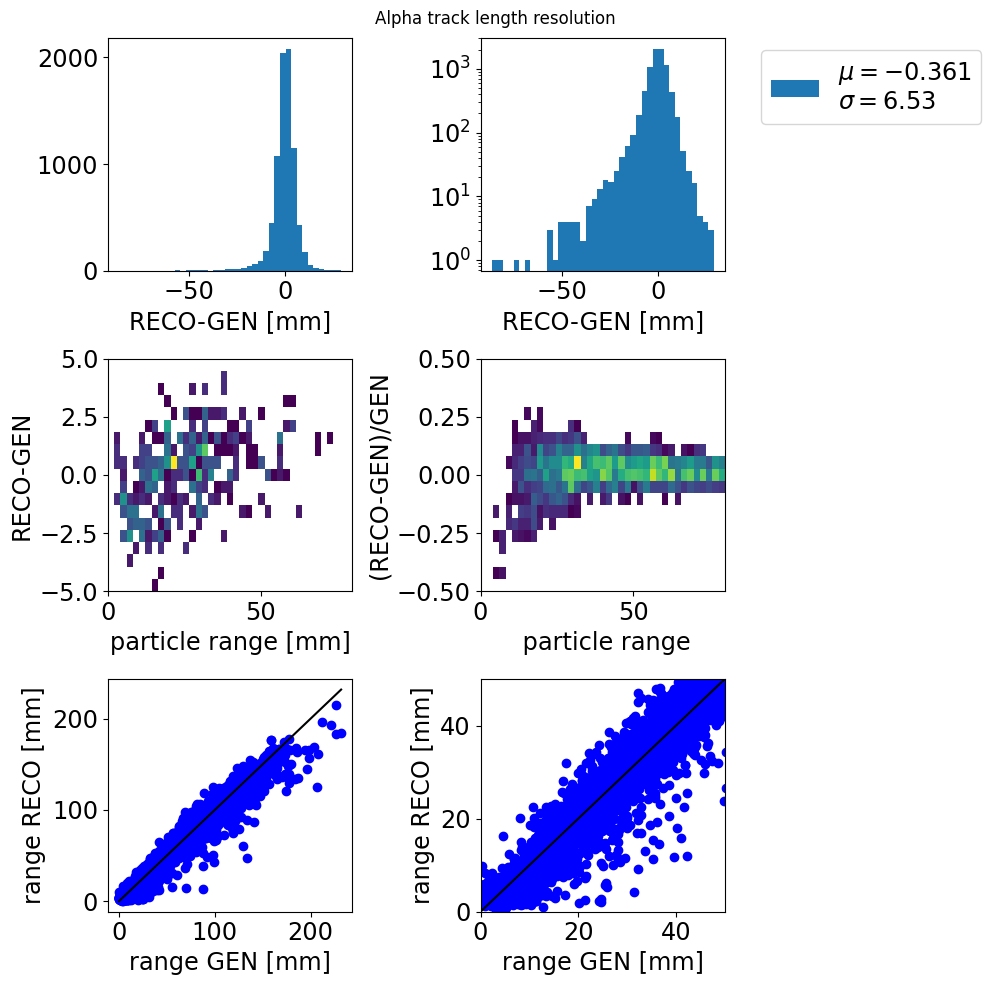

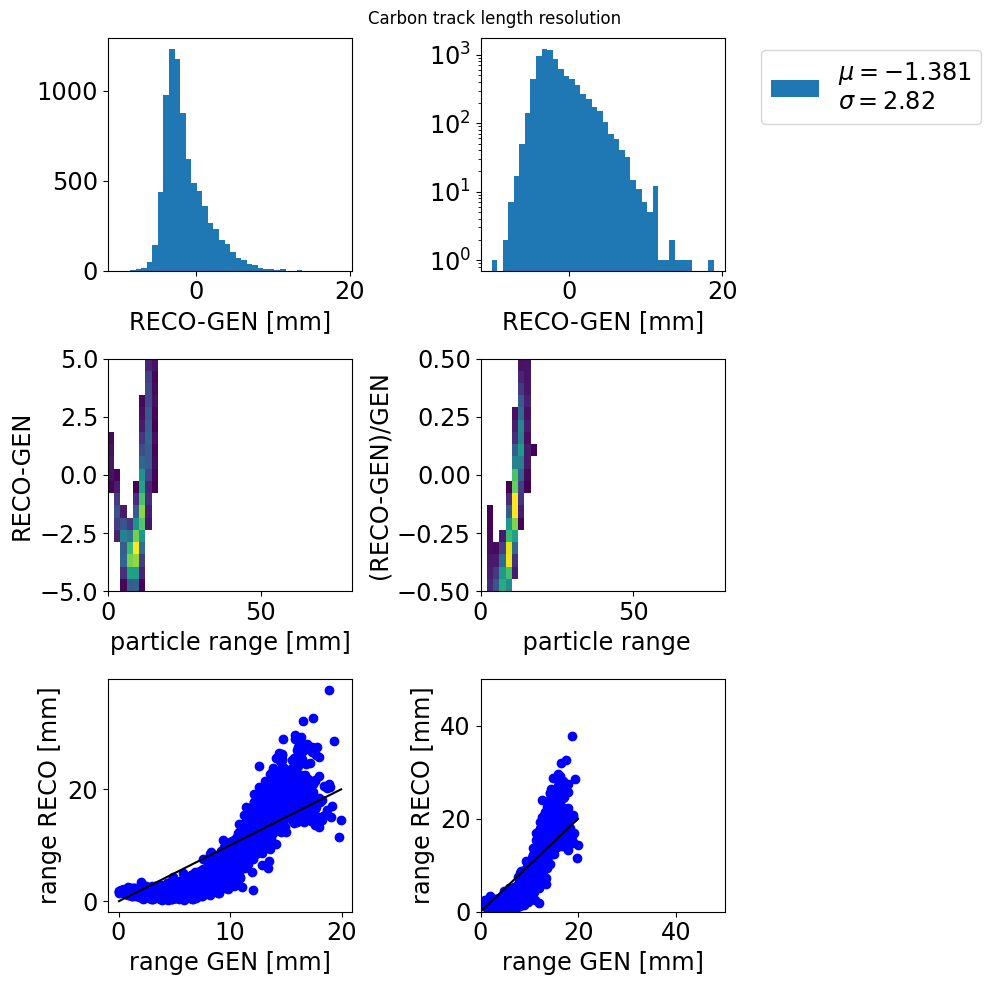

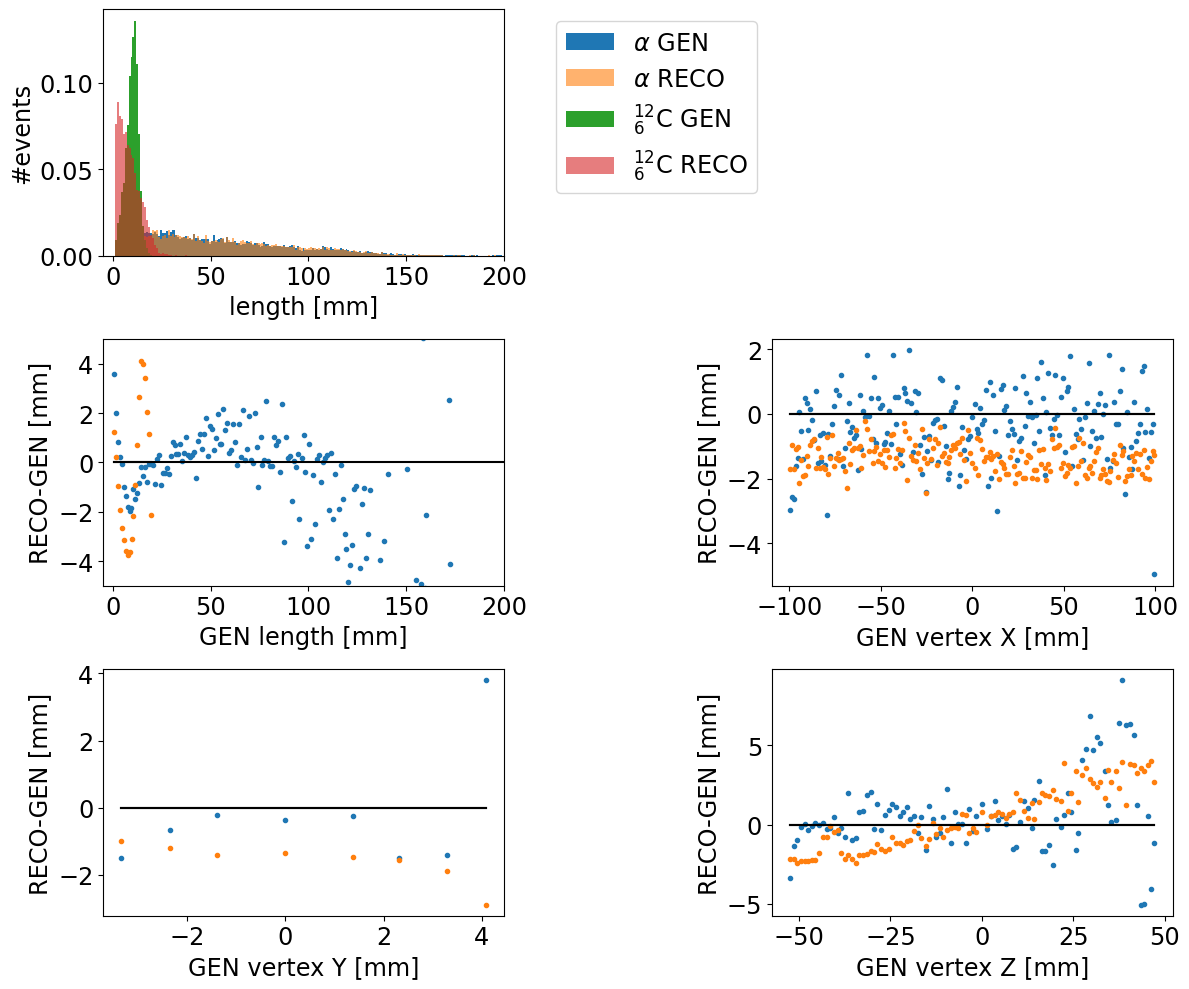

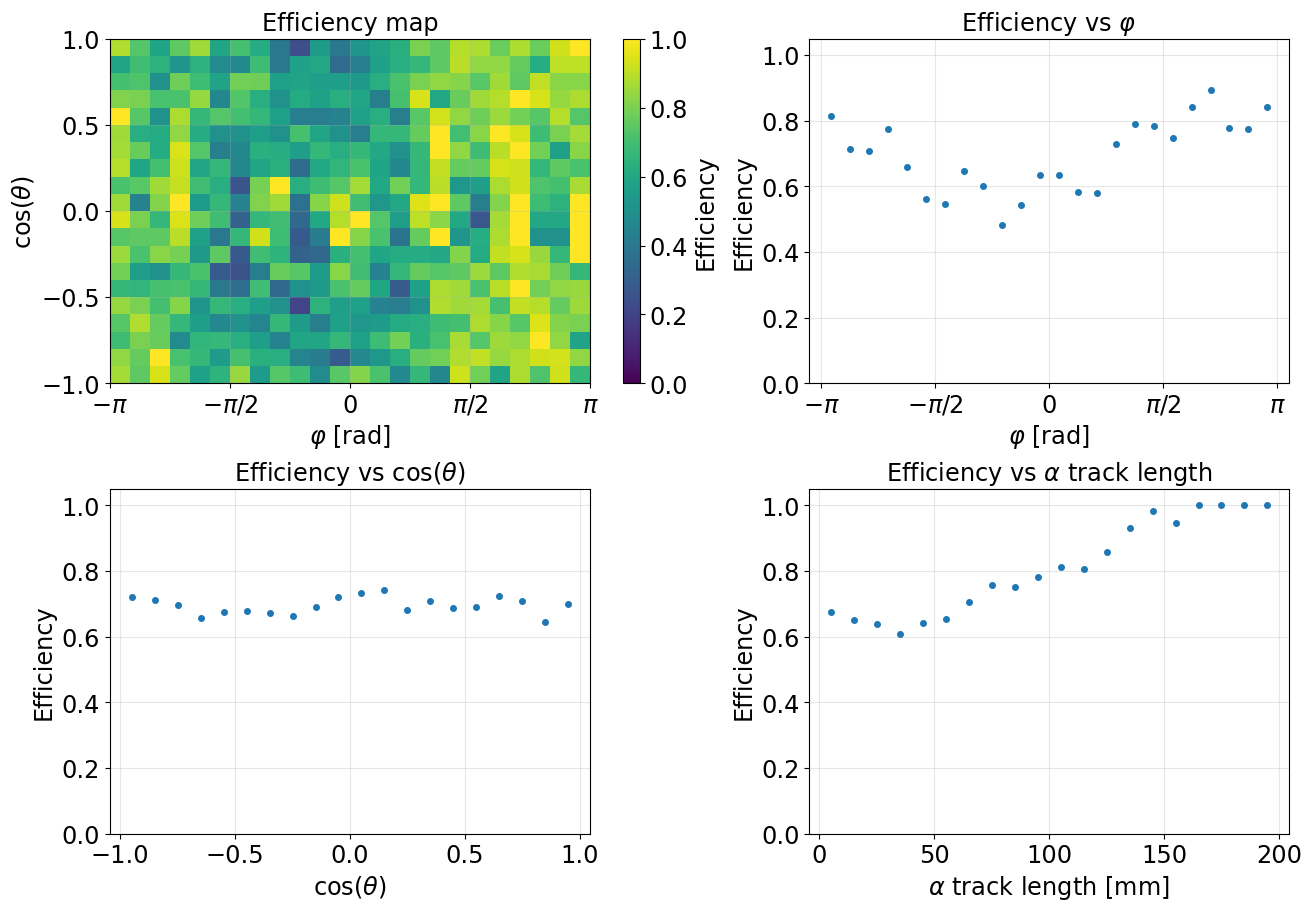

In [21]:
import plotting_functions as plf
importlib.reload(plf)

#plf.controlPlots(df)
# plf.plotEndPointRes(df=df_XYZ, edge="Vtx",coordinates=["x", "y", "z"])
# plf.plotEndPointRes(df=df_XYZ, edge="Alpha",coordinates=["x", "y", "z"])
# plf.plotEndPointRes(df=df_XYZ, edge="Carbon",coordinates=["x", "y", "z"])

plf.plotLengthPull(df_XYZ, partName="Alpha")
plf.plotLengthPull(df_XYZ, partName="Carbon")
plf.plotLengthPullEvolution(df_XYZ)
# plf.plotOpeningAngleCos(df_XYZ)

numeratorSelection = (df_XYZ["pullAlpha"]/df_XYZ["dAlpha_sim"] < 0.05)
denominatorSelection = (np.abs(df_XYZ["xAlpha_sim"]) < 140) & (np.abs(df_XYZ["yAlpha_sim"]) < 90) & (np.abs(df_XYZ["zAlpha_sim"]) < 60)

plf.plotEffMaps(df_XYZ, numeratorSelection, denominatorSelection)
pass